In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/Logistic_Regression_Assignment/diabetes.zip')

print("Shape:", df.shape)
df.head()

Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [7]:
print("Shape:", df.shape)
print("\nColumn Names:\n", df.columns.tolist())
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())
print("\nClass Distribution:")
print(df['Outcome'].value_counts())
print("\nBasic Statistics:")
df.describe()

Shape: (768, 9)

Column Names:
 ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

Data Types:
 Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

Missing Values:
 Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Class Distribution:
Outcome
0    500
1    268
Name: count, dtype: int64

Basic Statistics:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set(style="whitegrid")
print("Libraries imported ✅")

Libraries imported ✅


/tmp/ipykernel_5189/1346198670.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Outcome', data=df, palette='Set2')


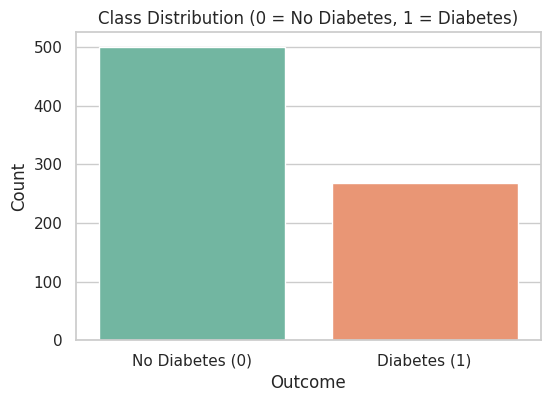

In [9]:
plt.figure(figsize=(6,4))
sns.countplot(x='Outcome', data=df, palette='Set2')
plt.title('Class Distribution (0 = No Diabetes, 1 = Diabetes)')
plt.xlabel('Outcome')
plt.ylabel('Count')
plt.xticks([0,1], ['No Diabetes (0)', 'Diabetes (1)'])
plt.show()

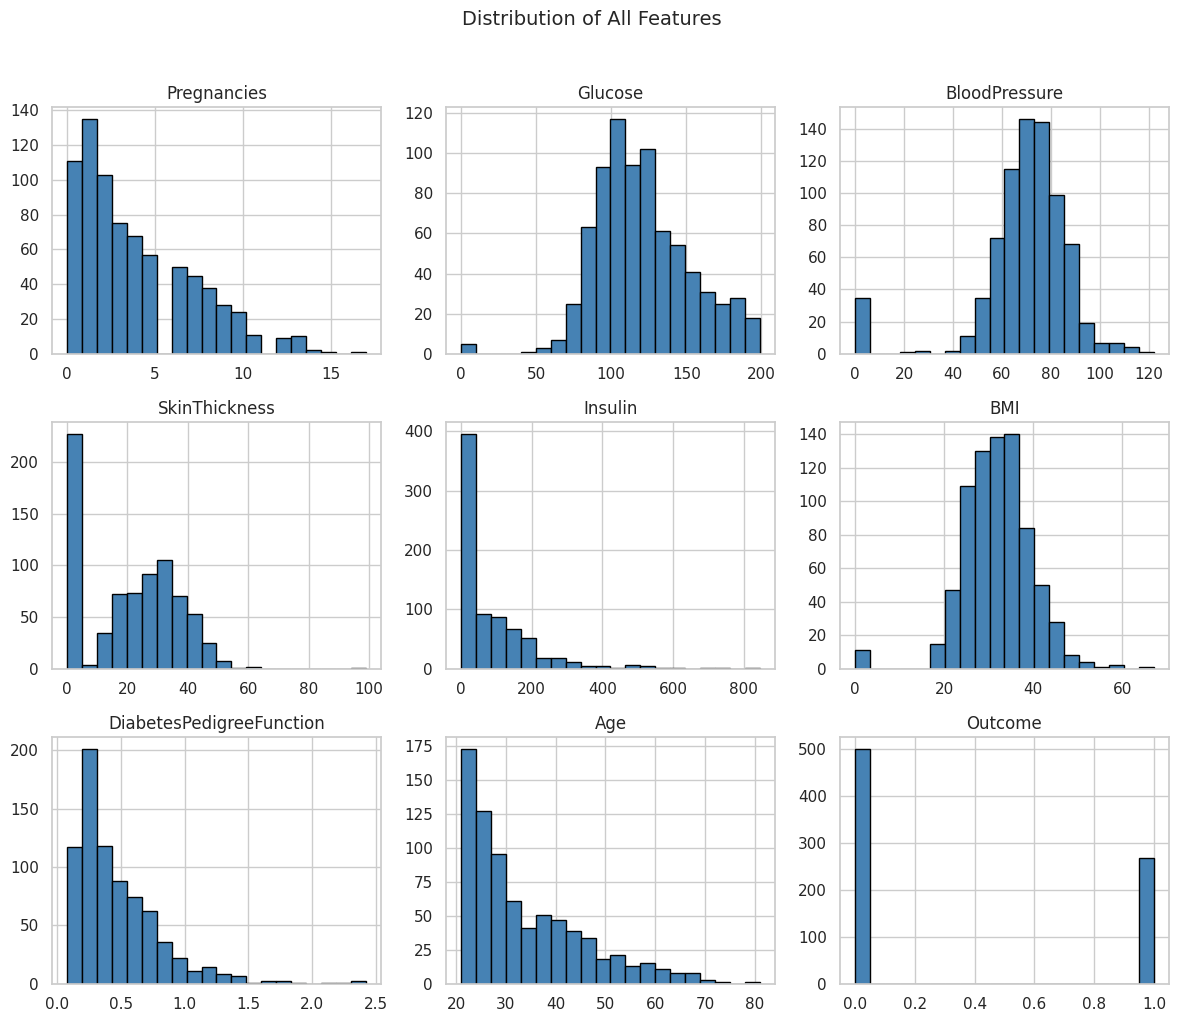

In [10]:
df.hist(figsize=(12,10), bins=20, color='steelblue', edgecolor='black')
plt.suptitle('Distribution of All Features', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

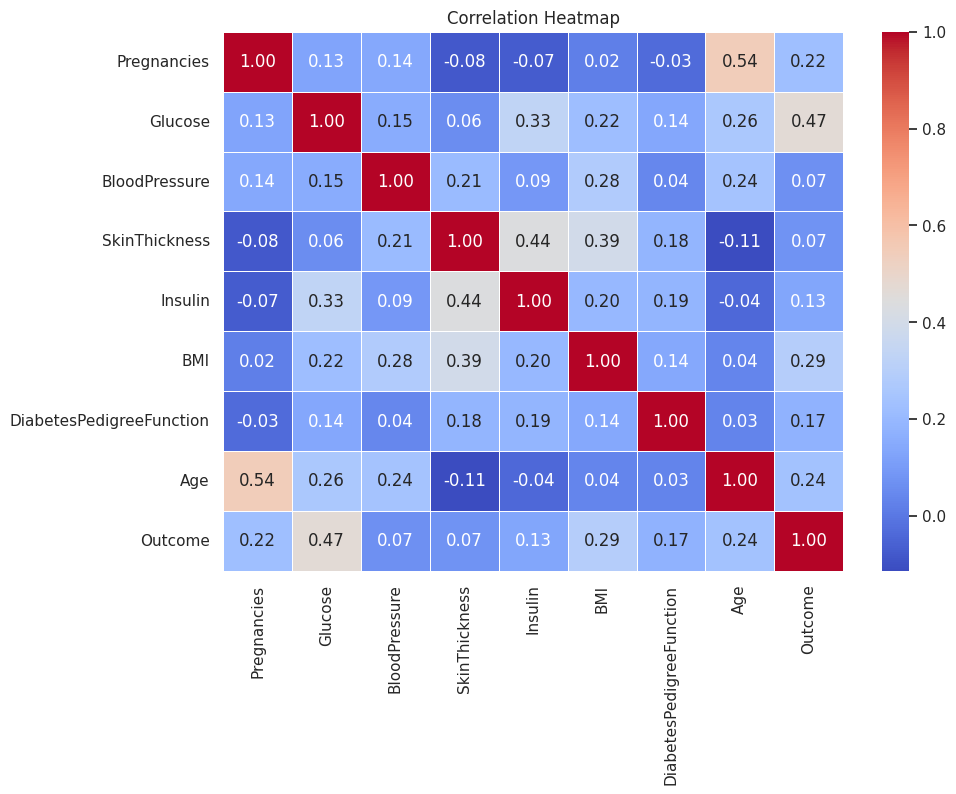

In [11]:
plt.figure(figsize=(10,7))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

/tmp/ipykernel_5189/3614493698.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Outcome', y=col, data=df, ax=axes[i], palette='Set2')
/tmp/ipykernel_5189/3614493698.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(['No Diabetes', 'Diabetes'])
/tmp/ipykernel_5189/3614493698.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Outcome', y=col, data=df, ax=axes[i], palette='Set2')
/tmp/ipykernel_5189/3614493698.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(['No Di

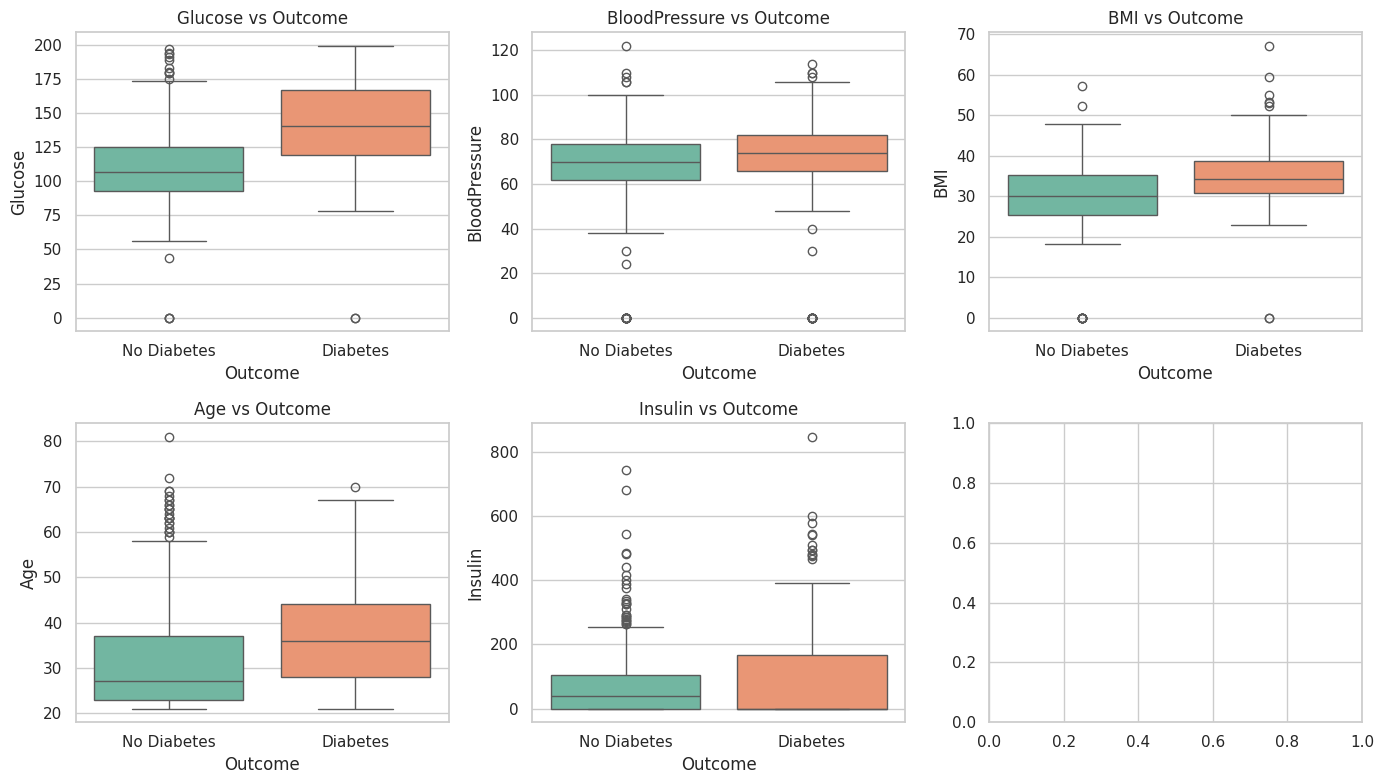

In [12]:
features = ['Glucose', 'BloodPressure', 'BMI', 'Age', 'Insulin']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.boxplot(x='Outcome', y=col, data=df, ax=axes[i], palette='Set2')
    axes[i].set_title(f'{col} vs Outcome')
    axes[i].set_xticklabels(['No Diabetes', 'Diabetes'])

plt.tight_layout()
plt.show()

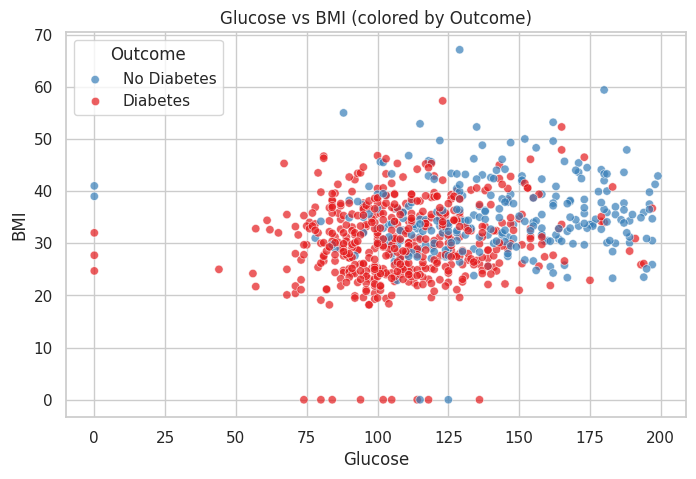

In [13]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Glucose', y='BMI', hue='Outcome',
                data=df, palette='Set1', alpha=0.7)
plt.title('Glucose vs BMI (colored by Outcome)')
plt.xlabel('Glucose')
plt.ylabel('BMI')
plt.legend(title='Outcome', labels=['No Diabetes', 'Diabetes'])
plt.show()

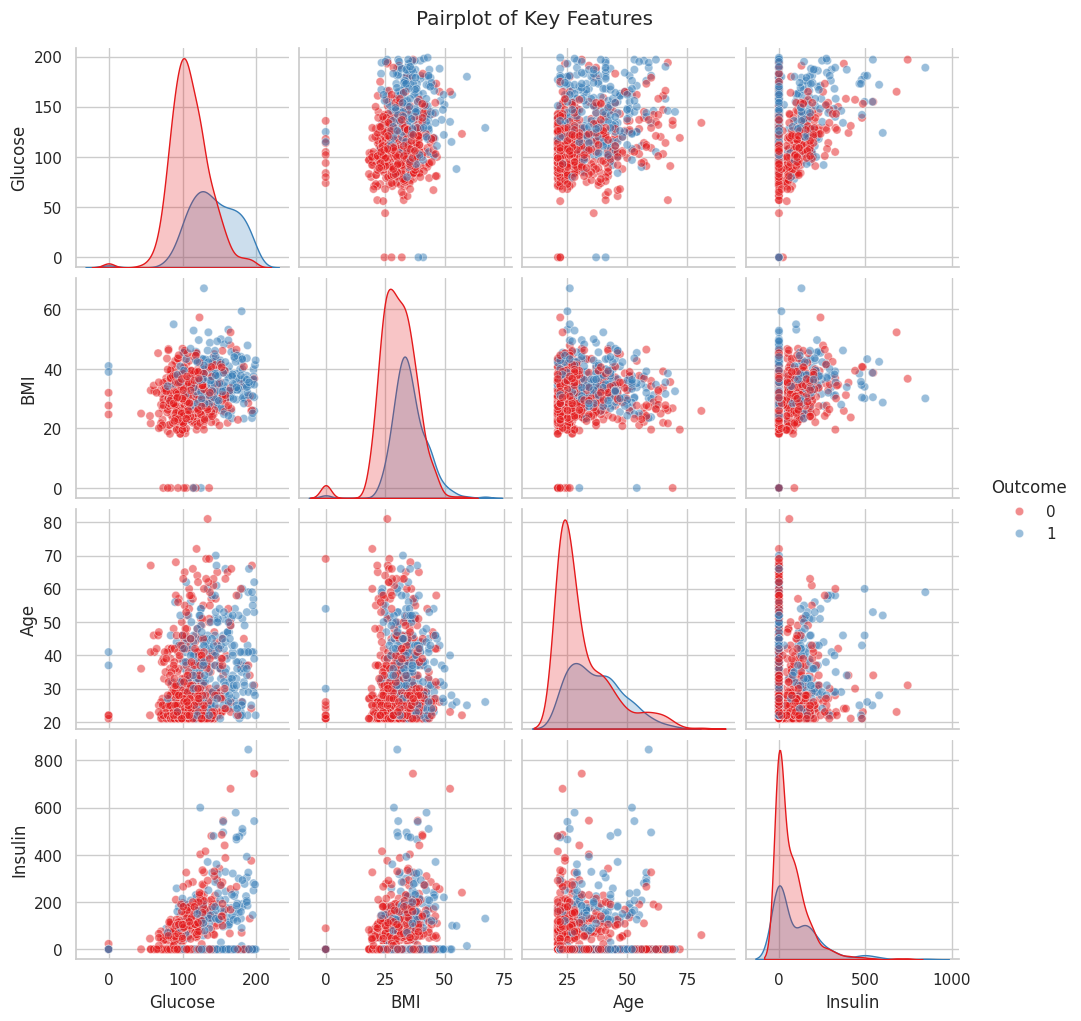

In [14]:
key_cols = ['Glucose', 'BMI', 'Age', 'Insulin', 'Outcome']
sns.pairplot(df[key_cols], hue='Outcome',
             palette='Set1', diag_kind='kde', plot_kws={'alpha':0.5})
plt.suptitle('Pairplot of Key Features', y=1.02)
plt.show()

In [15]:
# In this dataset 0 values in these columns are actually missing values
zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# Replace 0s with NaN
df[zero_cols] = df[zero_cols].replace(0, np.nan)

print("Zero values replaced with NaN ✅")
print("\nMissing Values Now:\n", df.isnull().sum())

Zero values replaced with NaN ✅

Missing Values Now:
 Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


In [16]:
# Fill NaN with median of each column
df[zero_cols] = df[zero_cols].fillna(df[zero_cols].median())

print("Missing values filled with median ✅")
print("\nMissing Values After Filling:\n", df.isnull().sum())

Missing values filled with median ✅

Missing Values After Filling:
 Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [17]:
X = df.drop(columns=['Outcome'])
y = df['Outcome']

print("Features shape:", X.shape)
print("Target shape  :", y.shape)
print("\nFeatures used:\n", X.columns.tolist())

Features shape: (768, 8)
Target shape  : (768,)

Features used:
 ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']


In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Normalization done ✅")
print("Sample scaled values:\n", X_scaled[:3])

Normalization done ✅
Sample scaled values:
 [[ 0.63994726  0.86604475 -0.03198993  0.67064253 -0.18154124  0.16661938
   0.46849198  1.4259954 ]
 [-0.84488505 -1.20506583 -0.5283186  -0.01230129 -0.18154124 -0.85219976
  -0.36506078 -0.19067191]
 [ 1.23388019  2.01666174 -0.69376149 -0.01230129 -0.18154124 -1.33250021
   0.60439732 -0.10558415]]


In [19]:
from sklearn.model_selection import train_test_split

# First split — 80% train, 20% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)

# Second split — 50% validation, 50% test (from the 20% temp)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42)

print("Data Split done ✅")
print(f"Training set   : {X_train.shape[0]} samples")
print(f"Validation set : {X_val.shape[0]} samples")
print(f"Test set       : {X_test.shape[0]} samples")

Data Split done ✅
Training set   : 614 samples
Validation set : 77 samples
Test set       : 77 samples


In [20]:
from sklearn.linear_model import LogisticRegression

# Create the model
model = LogisticRegression(max_iter=1000, random_state=42)

# Train the model
model.fit(X_train, y_train)

print("Model trained successfully ✅")

Model trained successfully ✅


In [21]:
from sklearn.metrics import accuracy_score

# Predict on validation set
y_val_pred = model.predict(X_val)

val_accuracy = accuracy_score(y_val, y_val_pred)
print(f"Validation Accuracy: {val_accuracy*100:.2f}%")

Validation Accuracy: 79.22%


In [22]:
# Predict classes
y_pred = model.predict(X_test)

# Predict probabilities
y_prob = model.predict_proba(X_test)[:, 1]

print("Predictions done ✅")
print("\nFirst 5 Predicted Classes     :", y_pred[:5])
print("First 5 Actual Classes        :", y_test.values[:5])
print("First 5 Probability Scores    :", y_prob[:5].round(3))

Predictions done ✅

First 5 Predicted Classes     : [0 1 0 0 0]
First 5 Actual Classes        : [1 0 1 0 1]
First 5 Probability Scores    : [0.404 0.526 0.27  0.241 0.479]


In [23]:
from sklearn.metrics import (accuracy_score, precision_score,
                              recall_score, f1_score, roc_auc_score)

accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)
auc       = roc_auc_score(y_test, y_prob)

print("=" * 40)
print("       EVALUATION METRICS")
print("=" * 40)
print(f"  Accuracy  : {accuracy*100:.2f}%")
print(f"  Precision : {precision*100:.2f}%")
print(f"  Recall    : {recall*100:.2f}%")
print(f"  F1 Score  : {f1*100:.2f}%")
print(f"  AUC Score : {auc:.4f}")
print("=" * 40)

       EVALUATION METRICS
  Accuracy  : 71.43%
  Precision : 64.29%
  Recall    : 60.00%
  F1 Score  : 62.07%
  AUC Score : 0.8326


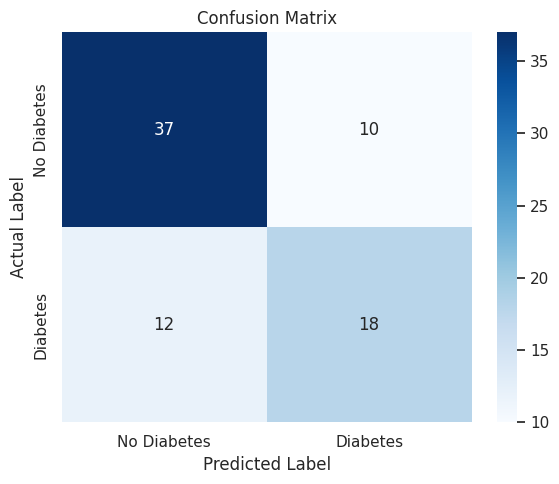

In [24]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.tight_layout()
plt.show()

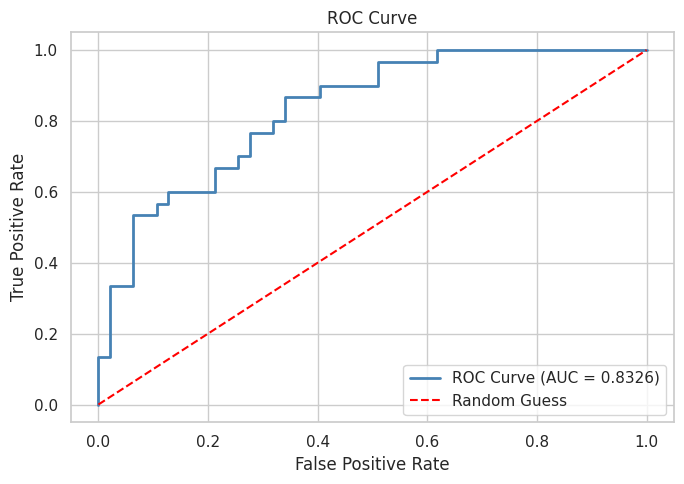

In [25]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, color='steelblue', linewidth=2,
         label=f'ROC Curve (AUC = {auc:.4f})')
plt.plot([0,1], [0,1], color='red', linestyle='--', label='Random Guess')
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.tight_layout()
plt.show()

In [26]:
sample = pd.DataFrame({
    'Actual'     : y_test.values[:10],
    'Predicted'  : y_pred[:10],
    'Probability': y_prob[:10].round(3)
})

sample['Result'] = sample.apply(
    lambda row: '✅ Correct' if row['Actual'] == row['Predicted']
    else '❌ Wrong', axis=1)

print("📋 Sample Predictions:")
print(sample.to_string(index=False))

📋 Sample Predictions:
 Actual  Predicted  Probability    Result
      1          0        0.404   ❌ Wrong
      0          1        0.526   ❌ Wrong
      1          0        0.270   ❌ Wrong
      0          0        0.241 ✅ Correct
      1          0        0.479   ❌ Wrong
      0          1        0.633   ❌ Wrong
      1          1        0.725 ✅ Correct
      1          1        0.559 ✅ Correct
      1          1        0.975 ✅ Correct
      0          0        0.040 ✅ Correct
